<a href="https://colab.research.google.com/github/avishek-astra/Deep_Learning_Experiments/blob/main/CNN_codeChallengeLinearUnits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

#summary info on labels
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
#use GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


Create Gaussian blurs with different width

In [3]:
nPerClass=1000
imgSize=91

x=np.linspace(-4,4,imgSize)
X,Y=np.meshgrid(x,x)

#the two widths(a.u.)
widths=[1.8,2.4]

#initialize tensors containing images and labels
images=torch.zeros(2*nPerClass,1,imgSize,imgSize)
labels=torch.zeros(2*nPerClass)

for i in range(2*nPerClass):
  #create the guassian with random centers
  ro=2*np.random.randn(2)
  G=np.exp(-((X-ro[0])**2+(Y-ro[1])**2)/(2*widths[i%2]**2))

  #and add noise
  G=G+np.random.randn(imgSize,imgSize)/5

  ##add to the tensor
  images[i,:,:,:]=torch.Tensor(G).view(1,imgSize,imgSize)
  labels[i]=i%2
labels=labels[:,None]


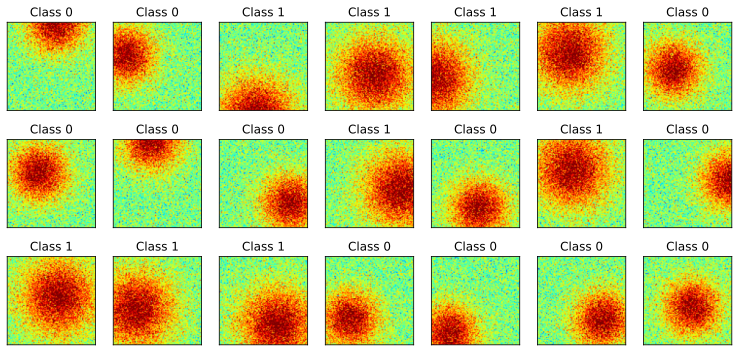

In [4]:
#visualize some images
fig,axs=plt.subplots(3,7,figsize=(13,6))
for i,ax in enumerate(axs.flatten()):
  whichpic=np.random.randint(2*nPerClass)
  G=np.squeeze(images[whichpic,:,:])
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet')
  ax.set_title('Class %s'%int(labels[whichpic].item()))
  ax.set_xticks([])
  ax.set_yticks([])
plt.show()

Create train/test groups using DataLoader

In [5]:
#step 1: use scikitlearn to split the data
train_data,test_data,train_labels,test_labels=train_test_split(images,labels,test_size=0.1)
#step 3:convert into Pytorch Datasets
train_data=TensorDataset(train_data,train_labels)
test_data=TensorDataset(test_data,test_labels)

#Step 4: translate into dataloader objects
batchsize=32
train_loader=DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader=DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [6]:
#check size
print(train_data.tensors[0].shape)
print(train_data.tensors[1].shape)

torch.Size([1800, 1, 91, 91])
torch.Size([1800, 1])


Create the DL model

In [8]:
from typing import NewType
#create a class for the model
def makeTheNet(fcUnits):
  class gausnet(nn.Module):
    def __init__(self):
      super().__init__()
      #all layers in one go using nn.Sequential
      self.enc=nn.Sequential(
          nn.Conv2d(1,6,3,padding=1),  # output size: (91+2*1-3)/1 + 1 = 91
          nn.ReLU(),                   # note that relu is treated like a "layer"
          nn.AvgPool2d(2,2),           # output size: 91/2 = 45
          nn.Conv2d(6,4,3,padding=1),  # output size: (45+2*1-3)/1 + 1 = 45
          nn.ReLU(),
          nn.AvgPool2d(2,2),           # output size: 45/2 = 22
          nn.Flatten(),                # vectorize conv output
          nn.Linear(22*22*4,2*fcUnits),
          nn.ReLU(),
          nn.Linear(2*fcUnits,fcUnits),
          nn.Linear(fcUnits,1),
        )

    def forward(self,x):
      return self.enc(x)

  #create the model instance
  net=gausnet()
  #loss function
  lossfun=nn.BCEWithLogitsLoss()
  #optimizer
  optimizer=torch.optim.Adam(net.parameters(),lr=0.001)
  return net,lossfun,optimizer


Create a function that trains the model

In [13]:
# a function that trains the model
def function2trainTheModel(fcUnits):
  #number of epochs
  numepochs=10
  #create a new model
  net,lossfun,optimizer=makeTheNet(fcUnits)
  #send the model to the GPU
  net.to(device)

  #initialize losses
  trainLoss=torch.zeros(numepochs)
  testLoss=torch.zeros(numepochs)
  trainAcc=torch.zeros(numepochs)
  testAcc=torch.zeros(numepochs)

  #loop over epochs
  for epochi in range(numepochs):
    #loop over training data batches
    net.train()
    batchLoss=[]
    batchAcc=[]
    for X,y in train_loader:
      #push data to GPU
      X,y=X.to(device),y.to(device)
      #forward pass and loss
      yHat=net(X)
      loss=lossfun(yHat,y)
      #backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      #loss from this batch
      batchLoss.append(loss.item())
      batchAcc.append(torch.mean(((yHat>0)==y).float()).item())

    #end of batch loop...
    #and get average losses across the batches
    trainLoss[epochi]=np.mean(batchLoss)
    trainAcc[epochi]=100*np.mean(batchAcc)

    #test accuracy
    X,y=next(iter(test_loader))
    #push data to GPU
    X,y=X.to(device),y.to(device)
    with torch.no_grad():
      yHat=net(X)
      loss=lossfun(yHat,y)
    #compare the following really long line of code to the training accuracy lines
    testLoss[epochi]=loss.item()
    testAcc[epochi]=100*torch.mean(((yHat>0)==y).float()).item()
  #end epochs

  #function output

  return trainLoss,testLoss,trainAcc,testAcc,net

Run the model and show the results!

In [14]:
#crazy note:this cell took 15 min in cpu
#specify number of hidden units
numberOfLinearUnits=np.round(np.linspace(5,500,20))

#initialize results matrix
results=np.zeros((len(numberOfLinearUnits),4))

for i,nunits in enumerate(numberOfLinearUnits):
  trainLoss,testLoss,trainAcc,testAcc,net=function2trainTheModel(int(nunits))
  results[i,:]=[trainLoss[-1],testLoss[-1],trainAcc[-1],testAcc[-1]]

/tmp/ipython-input-14-2426111183.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  results[i,:]=[trainLoss[-1],testLoss[-1],trainAcc[-1],testAcc[-1]]
/tmp/ipython-input-14-2426111183.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  results[i,:]=[trainLoss[-1],testLoss[-1],trainAcc[-1],testAcc[-1]]
/tmp/ipython-input-14-2426111183.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  results[i,:]=[trainLoss[-1],testLoss[-1],trainAcc[-1],testAcc[-1]]
/tmp/ipython-input-14-2426111183.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must imple

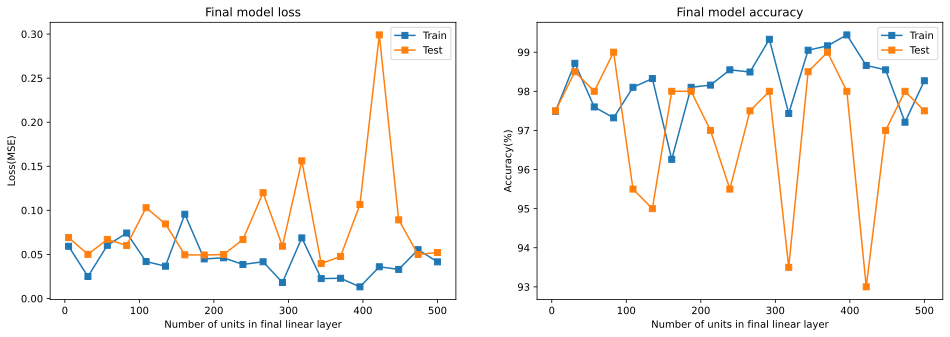

In [16]:
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(numberOfLinearUnits,results[:,:2],'s-')
ax[0].set_xlabel('Number of units in final linear layer')
ax[0].set_ylabel('Loss(MSE)')
ax[0].set_title('Final model loss')
ax[0].legend(['Train','Test'])

ax[1].plot(numberOfLinearUnits,results[:,2:],'s-')
ax[1].set_xlabel('Number of units in final linear layer')
ax[1].set_ylabel('Accuracy(%)')
ax[1].set_title('Final model accuracy')
ax[1].legend(['Train','Test'])

plt.show()

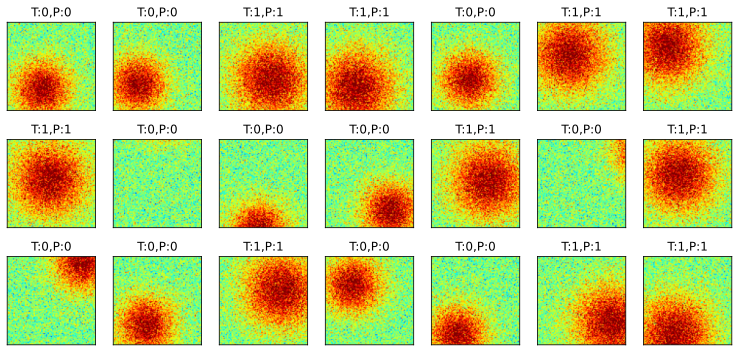

In [ ]:
#VISUALIZE SOME IMAGES
X,y=next(iter(test_loader))
yHat,featmap1,featmap2=net(X)

fig,axs=plt.subplots(3,7,figsize=(13,6))
for i,ax in enumerate(axs.flatten()):
  G=torch.squeeze(X[i,0,:,:]).detach()
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet')
  t=(int(y[i].item()),int(yHat[i].item()>0))
  ax.set_title('T:%s,P:%s'%t)
  ax.set_xticks([])
  ax.set_yticks([])
plt.show()

Draw the feature maps

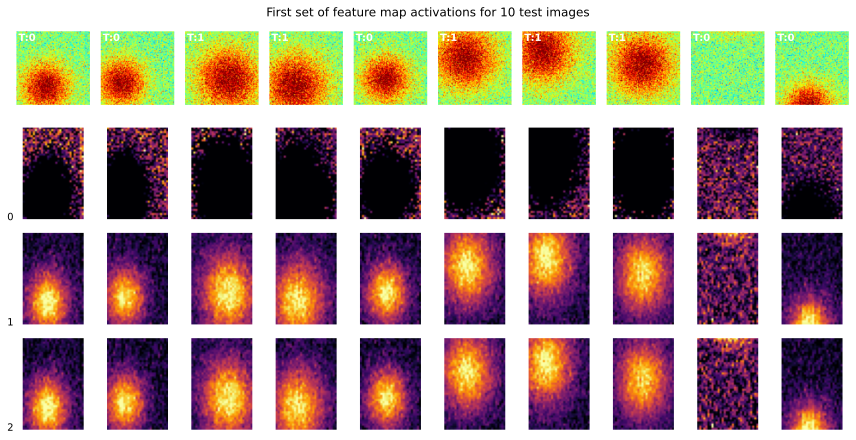

In [ ]:
#feature maps from the conv1 layer
fig,axs=plt.subplots(featmap1.shape[1]+1,10,figsize=(12,6))
for pici in range(10):

  #show the original picture
  img=X[pici,0,:,:].detach()
  axs[0,pici].imshow(img,vmin=-1,vmax=1,cmap='jet')
  axs[0,pici].axis('off')
  axs[0,pici].text(2,2,'T:%s'%int(y[pici].item()),ha='left',va='top',color='w',fontweight='bold')

  for feati in range(featmap1.shape[1]):
    #extract the feature map from this image
    img=featmap1[pici,feati,:,:].detach()
    #show it
    axs[feati+1,pici].imshow(img,vmin=0,vmax=torch.max(img)*.9,cmap='inferno')
    axs[feati+1,pici].axis('off')
    axs[feati+1,pici].text(-5,45,feati,ha='right') if pici==0 else None
plt.tight_layout()
plt.suptitle('First set of feature map activations for 10 test images',x=.5,y=1.01)
plt.show()


/tmp/ipython-input-50-3846811388.py:18: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


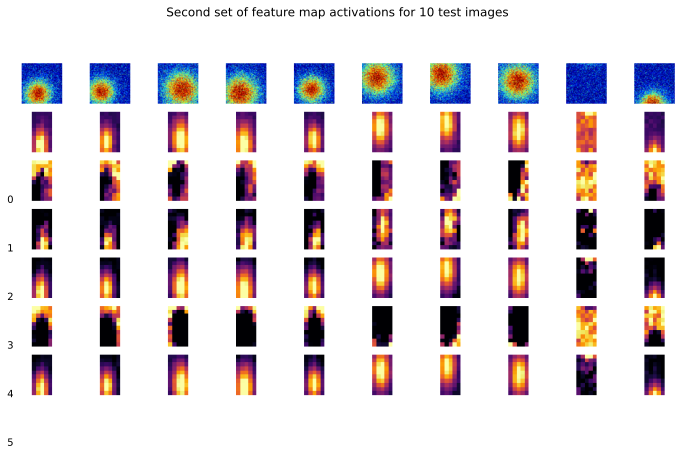

In [ ]:
#Repeat for feature2 maps
fig,axs = plt.subplots(featmap2.shape[1]+1,10,figsize=(12,6))

for pici in range(10):

  # show the original picture
  img = X[pici,0,:,:].detach()
  axs[0,pici].imshow(img,cmap='jet',vmin=0,vmax=1)
  axs[0,pici].axis('off')

  for feati in range(featmap2.shape[1]):
    # extract the feature map from this image
    img = featmap2[pici,feati,:,:].detach()
    axs[feati+1,pici].imshow(img,cmap='inferno',vmin=0,vmax=torch.max(img)*.9)
    axs[feati+1,pici].axis('off')
    axs[feati+1,pici].text(-5,22,feati,ha='right') if pici==0 else None

plt.tight_layout()
plt.suptitle('Second set of feature map activations for 10 test images',x=.5,y=1.01)
plt.show()

Spatial correlations across the feature maps

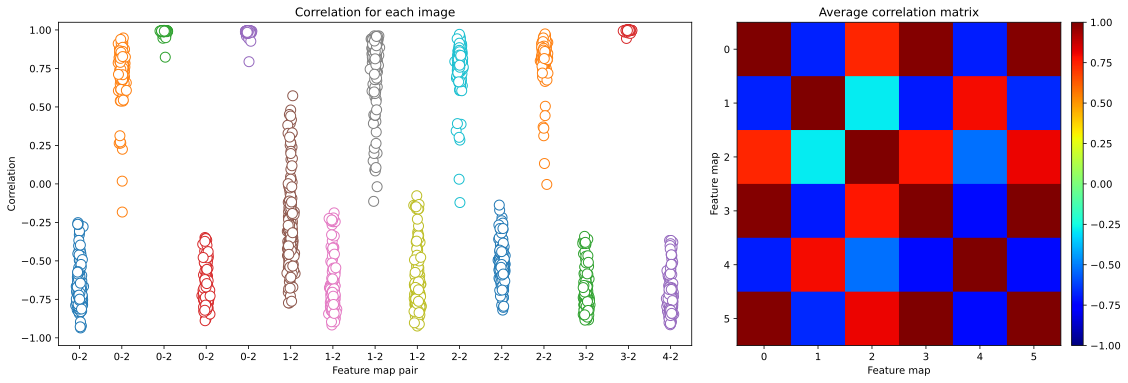

In [ ]:
###correlations across the SECOND convolution layer
#convenient variables
nStim=featmap2.shape[0]
nMaps=featmap2.shape[1]
nCors=(nMaps*(nMaps-1))//2

#initialize the matrix of all correlation values
allrs=np.zeros((nStim,nCors))
Call=np.zeros((nMaps,nMaps))

#loop over each stimulus
for i in range(nStim):
  ##extract the vectorized feature maps from this image
  featmaps=featmap2[i,:,:,:].view(nMaps,-1).detach()

  #compute the correlation matrix
  C=np.corrcoef(featmaps)
  Call+=C
  #extract the unique correlations from the matrix
  idx=np.nonzero(np.triu(C,k=1))
  allrs[i,:]=C[idx]
  #define the x-axis labels
  xlab=[]*nCors
  for i in range(nCors):
    xlab.append('%s-%s'%(idx[0][i],idx[1][1]))
##now visualize the correlations
fig=plt.figure(figsize=(16,5))
ax0=fig.add_axes([.1,.1,.55,.9])
ax1=fig.add_axes([.68,.1,.3,.9])
cax=fig.add_axes([.98,.1,.01,.9])
for i in range(nCors):
  ax0.plot(i+np.random.randn(nStim)/30,allrs[:,i],'o',markerfacecolor='w',markersize=10)
#make the plot more interpretable
ax0.set_xlim([-.5,nCors-.5])
ax0.set_ylim([-1.05,1.05])
ax0.set_xticks(range(nCors))
ax0.set_xticklabels(xlab)
ax0.set_xlabel('Feature map pair')
ax0.set_ylabel('Correlation')
ax0.set_title('Correlation for each image')

#now show the average correlation matrix
h=ax1.imshow(Call/nStim,cmap='jet',vmin=-1,vmax=1)
ax1.set_title('Average correlation matrix')
ax1.set_xlabel('Feature map')
ax1.set_ylabel('Feature map')
fig.colorbar(h,cax=cax)
plt.show()




  #fill the upper triangle of the correlation matrix

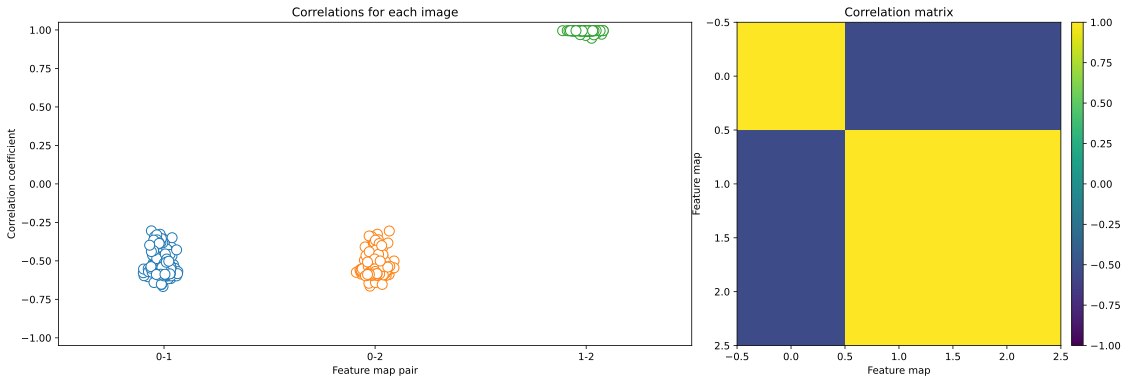

In [ ]:
### correlations across the FIRST convolution layer

# convenient variables
nStim = featmap1.shape[0]
nMaps = featmap1.shape[1]
nCors = (nMaps*(nMaps-1))//2

# initialze the matrix of all correlation values
allrs = np.zeros((nStim,nCors))
Call  = np.zeros((nMaps,nMaps))

# loop over each stimulus
for i in range(nStim):

  # extract the vectorized feature maps from this image
  featmaps = featmap1[i,:,:,:].view(nMaps,-1).detach()

  # compute the correlation matrix
  C = np.corrcoef(featmaps)
  Call += C

  # extract the unique correlations from the matrix
  idx = np.nonzero(np.triu(C,1))
  allrs[i,:] = C[idx]


# define the x-axis labels
xlab = []*nCors
for i in range(nCors):
  xlab.append('%s-%s' %(idx[0][i],idx[1][i]))




# now visualize the correlations
fig = plt.figure(figsize=(16,5))
ax0 = fig.add_axes([.1,.1,.55,.9]) # [left, bottom, width, height]
ax1 = fig.add_axes([.68,.1,.3,.9])
cax = fig.add_axes([.98,.1,.01,.9])

for i in range(nCors):
  ax0.plot(i+np.random.randn(nStim)/30,allrs[:,i],'o',markerfacecolor='w',markersize=10)

# make the plot more interpretable
ax0.set_xlim([-.5,nCors-.5])
ax0.set_ylim([-1.05,1.05])
ax0.set_xticks(range(nCors))
ax0.set_xticklabels(xlab)
ax0.set_xlabel('Feature map pair')
ax0.set_ylabel('Correlation coefficient')
ax0.set_title('Correlations for each image')


# now show the average correlation matrix
h = ax1.imshow(Call/nStim,vmin=-1,vmax=1)
ax1.set_title('Correlation matrix')
ax1.set_xlabel('Feature map')
ax1.set_ylabel('Feature map')
# add a colorbar
fig.colorbar(h,cax=cax)

plt.show()